# Análisis de Componentes Principales (PCA)

## 1. Teoría Subyacente (Primeros Principios)
El **Análisis de Componentes Principales (PCA)** es una técnica matemática de reducción de dimensionalidad. El objetivo es transformar el conjunto original de variables predictoras en un nuevo conjunto de variables incorrelacionadas (ortogonales) llamadas **Componentes Principales**. Cada nueva componente es una combinación lineal de las variables originales.

Esta transformación se realiza de manera jerárquica: la primera componente principal captura la mayor cantidad de varianza posible de los datos, la segunda captura la mayor cantidad de la varianza residual, y así sucesivamente.

**Pasos fundamentales implementados:**
1. **Estandarización:** Dado que PCA es sensible a la escala de las variables (maximiza la varianza), es obligatorio estandarizar los datos previamente para que cada característica contribuya de manera equitativa. Se utiliza media 0 y desviación estándar 1.
2. **Cálculo de PCA:** Reducimos la dimensionalidad del conjunto de datos a 2 componentes principales para permitir la visualización geométrica del espacio de características.
3. **Visualización:** Generación de un diagrama de dispersión para observar si existe separabilidad lineal intrínseca entre las clases.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuramos la semilla para asegurar reproducibilidad (Rigor Científico)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Carga de los datos de entrenamiento
train_data = pd.read_csv('data/training.csv')

# Separación de variables independientes y variable objetivo
# Asumimos que 'Unnamed: 0' puede existir como índice residual
X_features = train_data.drop(columns=['class', 'Unnamed: 0'], errors='ignore')
y_target = train_data['class']

print(f"Dimensiones de los datos originales (X): {X_features.shape}")

Dimensiones de los datos originales (X): (3000, 50)


## 2. Determinación del Número Óptimo de Componentes (Gráfica del Codo)

Antes de aplicar la transformación final para visualización 2D, utilizamos la "gráfica del codo" (Scree Plot) y la curva de varianza acumulada para determinar cuántas componentes principales son necesarias para retener una cantidad aceptable de información (por ejemplo, el 90% o 95% de la varianza original).
Para ello, calcularemos el PCA sobre todas las características estandarizadas y analizaremos la contribución de cada componente.

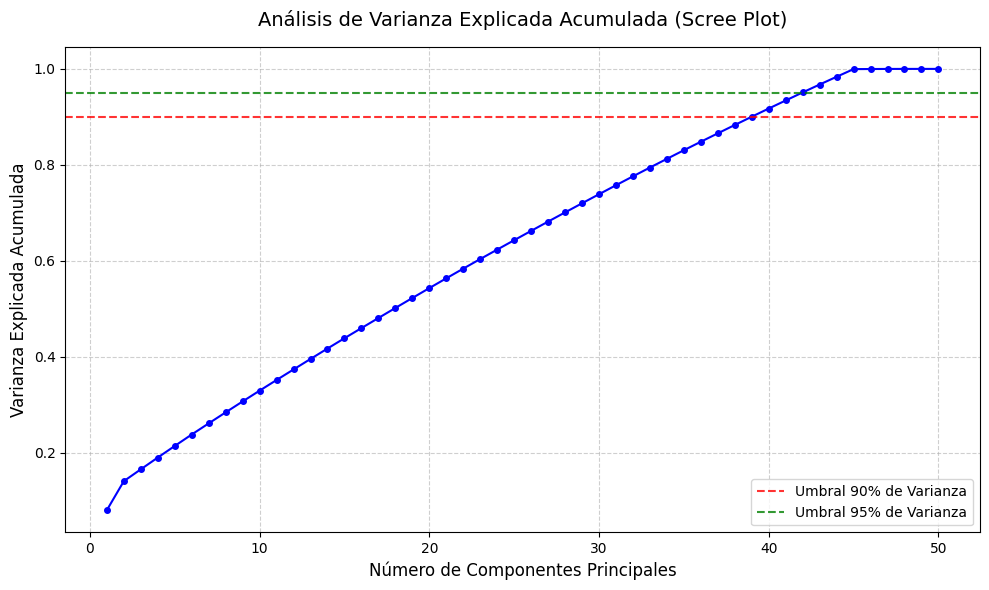

In [12]:
# Estandarizamos todas las características para la gráfica de varianza
scaler_test = StandardScaler()
X_scaled_test = scaler_test.fit_transform(X_features)

# Aplicamos PCA sin limitar el número de componentes
pca_test = PCA(random_state=RANDOM_SEED)
pca_test.fit(X_scaled_test)

# Calculamos la varianza explicada acumulada
cumulative_variance = np.cumsum(pca_test.explained_variance_ratio_)

# Generamos la gráfica del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='b', markersize=4)
plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.8, label='Umbral 90% de Varianza')
plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.8, label='Umbral 95% de Varianza')
plt.title('Análisis de Varianza Explicada Acumulada (Scree Plot)', fontsize=14, pad=15)
plt.xlabel('Número de Componentes Principales', fontsize=12)
plt.ylabel('Varianza Explicada Acumulada', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [16]:
# 3. Pipeline de Transformación

# 1. Instanciamos y aplicamos el StandardScaler (media 0, desviación estándar 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 2. Instanciamos y aplicamos PCA para 2 componentes
pca_model = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca_transformed = pca_model.fit_transform(X_scaled)

# Evaluamos la varianza retenida por nuestras componentes
explained_variance = pca_model.explained_variance_ratio_
print(f"Varianza explicada por PC1: {explained_variance[0]:.2%}")
print(f"Varianza explicada por PC2: {explained_variance[1]:.2%}")
print(f"Varianza total acumulada (2 componentes): {sum(explained_variance):.2%}")

# Creamos un DataFrame con los resultados para facilitar la visualización
pca_dataframe = pd.DataFrame(data=X_pca_transformed, columns=['PC1', 'PC2'])
pca_dataframe['class'] = y_target

Varianza explicada por PC1: 8.01%
Varianza explicada por PC2: 6.05%
Varianza total acumulada (2 componentes): 14.05%


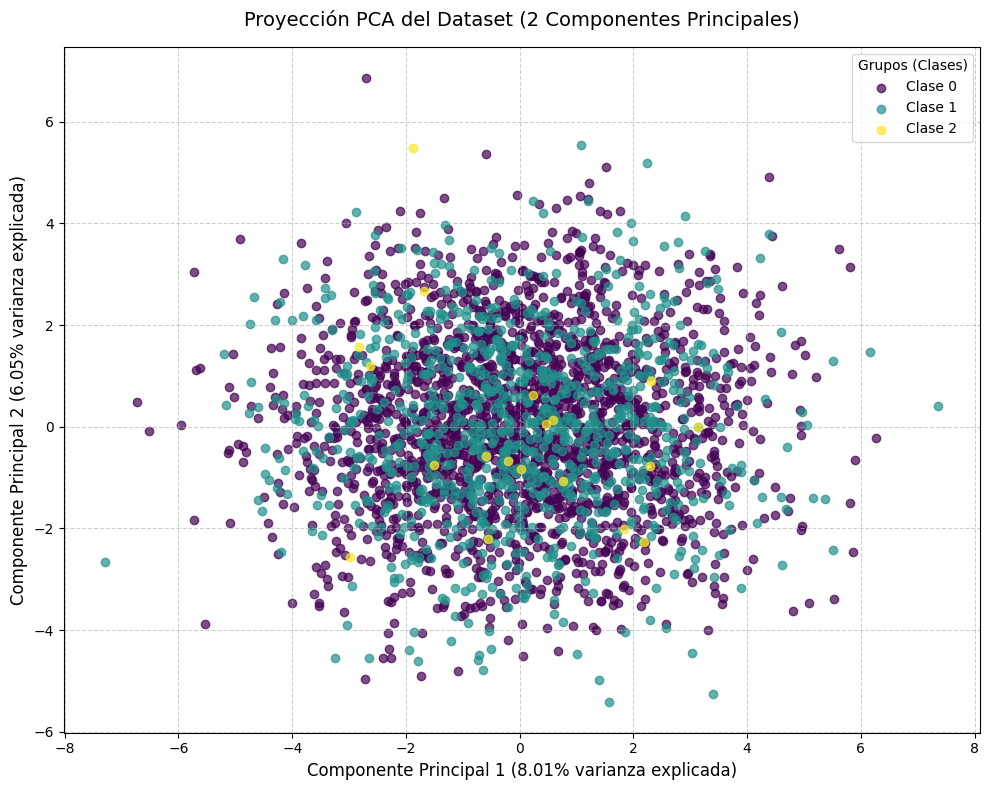

In [18]:
# 4. Visualización de los resultados (Scatter Plot)

plt.figure(figsize=(10, 8))

# Obtenemos las clases únicas y un mapa de colores
unique_classes = np.unique(y_target)
color_map = plt.cm.viridis(np.linspace(0, 1, len(unique_classes)))

# Generamos el gráfico de dispersión agrupado por clases
for target_class, color in zip(unique_classes, color_map):
    class_subset = pca_dataframe[pca_dataframe['class'] == target_class]
    plt.scatter(
        class_subset['PC1'], 
        class_subset['PC2'], 
        label=f'Clase {target_class}', 
        alpha=0.7, 
        c=[color]
    )

plt.title('Proyección PCA del Dataset (2 Componentes Principales)', fontsize=14, pad=15)
plt.xlabel(f'Componente Principal 1 ({explained_variance[0]:.2%} varianza explicada)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({explained_variance[1]:.2%} varianza explicada)', fontsize=12)
plt.legend(title='Grupos (Clases)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()